In [7]:
import imageio
from IPython.display import Video, display
from tqdm import tqdm
import matplotlib.pyplot as plt


# Load and Visualize a myoSuite model
In this notebook is shown how to load a model and visualize it

In [2]:
from myosuite.utils import gym
import os

MyoSuite:> Registering Myo Envs


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [6]:
env = gym.make('myoChallengeOslRunFixed-v0')
print('List of cameras available', [env.unwrapped.mj_model.camera(i).name for i in range(env.unwrapped.mj_model.ncam)])
env.reset()
frames = []
for _ in tqdm(range(200)):
    frame = env.unwrapped.mj_renderer.render_offscreen(camera_id=1)
    frames.append(frame)
    env.step(env.action_space.sample()) # take a random action
env.close()

os.makedirs('videos', exist_ok=True) # make a local copy
try:
    imageio.mimwrite(f"videos/temp.mp4", frames, fps=1.0 / env.unwrapped.dt)
except Exception as e:
    print('WARNING: imageio.mimwrite failed:', e)

# show in the notebook
display(Video(f"videos/temp.mp4", embed=True))

List of cameras available ['topview', 'side_view', 'agent_view']


100%|██████████| 200/200 [00:22<00:00,  8.78it/s]


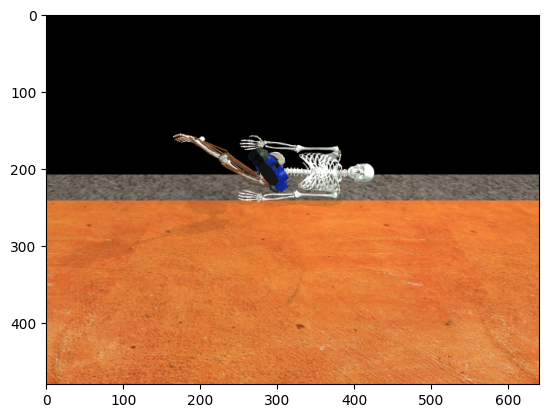

In [8]:
plt.imshow(frame)